# Fitting a spatial absorption field

Real detector water is not perfectly uniform — the absorption length varies in space
(temperature gradients, impurity stratification, …). LUCiD models this with a **pluggable,
differentiable spatial field** that multiplies the absorption coefficient:

$$\mu_\text{eff}(x)\;=\;\frac{1}{L_\text{abs}}\;\cdot\;\text{abs\_dev}(\lambda)\;\cdot\;\text{field}(x)$$

The field's parameters live in `DetectorParams.absorption.field_params` and flow through autodiff
like any optical parameter, so a spatial field can be **fit by gradient descent** from calibration
light. This notebook

1. configures a `poly` spatial field on an SK-like cylinder,
2. generates calibration charge from a **known** truth field,
3. recovers `field_params` with Adam on the charge mismatch,
4. visualises truth vs. recovered field.

> **GPU recommended** (~2–3 min). On CPU it is much slower — set `JAX_PLATFORM_NAME=cpu` and expect minutes.

## 1. Setup — a calibration sim with a spatial field

In [1]:
import os
# Resolve config paths whether this notebook is launched from the repo root or its own folder.
while not os.path.isdir('config') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')

import jax, jax.numpy as jnp, numpy as np, optax
import matplotlib.pyplot as plt
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import laser_source, isotropic_source
from lucid.detector_params import DetectorParams
from lucid.simulation.fields import make_field

GEOM = 'config/SK_like_geom_config.json'
det = generate_detector(GEOM)
NS, R, H = len(det.all_points), float(det.r), float(det.H)
top, bot = H/2 - 0.1, -H/2 + 0.1

# 'poly' = low-order Chebyshev(r) x Chebyshev(z) x azimuth. It is SELF-GAUGING (the pure-constant
# mode is excluded), so the field carries only spatial *deviation* and never competes with the
# global L_abs. Here: degree 2 in r and z, axisymmetric (n_azim=0) -> 8 free coefficients.
HP = dict(deg_r=2, deg_z=2, n_azim=0)
apply, init = make_field('poly', R=R, H=H, **HP)
print(f"{NS} PMTs, R={R:.1f} m, H={H:.1f} m; poly field has {init.size} free coefficients")

# Calibration sim: sim(source, detector_params, key) -> (charge, time). The field is wired in via
# absorption_field='poly' (+ matching field_hparams); it multiplies the absorption per photon step.
sim = setup_event_simulator(GEOM, 600_000, temperature=None, K=8, is_calibration=True,
                            hit_mode='aggregated', wavelength_mode=False,
                            absorption_field='poly', field_hparams=HP,
                            n_cap=80, n_angular=120, n_height=80)

10764 PMTs, R=16.9 m, H=36.2 m; poly field has 8 free coefficients


## 2. A known truth field + calibration data

We fix the global optics and inject a nontrivial spatial field (~10 % absorption deviation), then generate the per-PMT charge for three calibration sources.

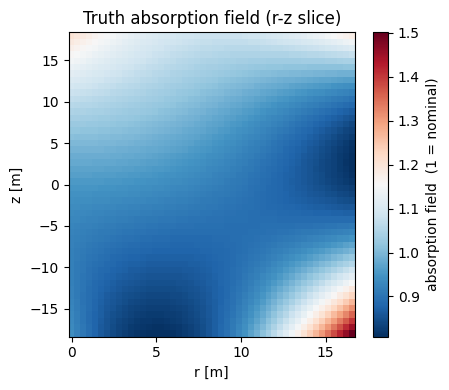

In [2]:
# Baseline optical globals — known/fixed here; we fit only the spatial field.
dp0 = DetectorParams.from_flat(scatter_length=70., mie_scatter_length=3000., g=0.9,
                               wall_reflection_rate=.2, sensor_reflection_rate=.2,
                               absorption_length=60., qe=0.07, qe_corrections=jnp.ones(NS))
def with_field(coeffs):
    return dp0._replace(absorption=dp0.absorption._replace(field_params=coeffs))

# A nontrivial truth field (~10% spatial deviation in absorption).
truth_coeffs = jnp.asarray(0.12 * np.random.default_rng(1).standard_normal(init.shape), jnp.float32)

# Three calibration sources for r-z coverage: lasers down/up the axis + a central isotropic flasher.
sources = [laser_source(position=[0, 0, top], direction=[0, 0, -1], intensity=1e6),
           laser_source(position=[0, 0, bot], direction=[0, 0,  1], intensity=1e6),
           isotropic_source(position=[0, 0, 0], intensity=1e6)]
key = jax.random.PRNGKey(0)
truth_charge = [sim(s, with_field(truth_coeffs), key)[0] for s in sources]

# Evaluate a field's correction on an r-z slice (theta=0), as a 2D map for plotting.
rr = np.linspace(0, R*0.98, 48); zz = np.linspace(bot, top, 48)
RR, ZZ = np.meshgrid(rr, zz)
slice_pts = jnp.asarray(np.stack([RR.ravel(), np.zeros(RR.size), ZZ.ravel()], -1), jnp.float32)
def field_map(coeffs):
    return np.asarray(apply(coeffs, slice_pts)).reshape(RR.shape)

plt.figure(figsize=(4.6, 4))
plt.pcolormesh(rr, zz, field_map(truth_coeffs), cmap='RdBu_r', shading='auto')
plt.colorbar(label='absorption field  (1 = nominal)')
plt.xlabel('r [m]'); plt.ylabel('z [m]'); plt.title('Truth absorption field (r-z slice)')
plt.tight_layout(); plt.show()

## 3. Fit `field_params` by gradient descent

`field_params` is just another leaf of the differentiable `DetectorParams` pytree, so we can
take `jax.grad` of a charge-mismatch loss straight through the photon transport and let Adam
recover it. We start from the homogeneous field (all-zero coefficients ⇒ field ≡ 1).

In [3]:
@jax.jit
def loss(coeffs):
    dp = with_field(coeffs)
    return sum(jnp.mean((sim(s, dp, key)[0] - qt)**2) for s, qt in zip(sources, truth_charge))

opt = optax.adam(optax.cosine_decay_schedule(3e-2, 280, 0.05))
coeffs = jnp.zeros_like(init)             # start homogeneous (field = 1 everywhere)
state = opt.init(coeffs)
vg = jax.jit(jax.value_and_grad(loss))

loss_hist, err_hist = [], []
for i in range(280):
    l, g = vg(coeffs)
    upd, state = opt.update(g, state, coeffs); coeffs = optax.apply_updates(coeffs, upd)
    loss_hist.append(float(l)); err_hist.append(float(jnp.linalg.norm(coeffs - truth_coeffs)))
    if i % 40 == 0 or i == 279:
        print(f"step {i:3d}  loss={float(l):.3e}  coeff-err={err_hist[-1]:.4f}")

step   0  loss=5.909e-02  coeff-err=0.2233


step  40  loss=1.333e-03  coeff-err=0.1501


step  80  loss=3.727e-04  coeff-err=0.1249


step 120  loss=2.005e-04  coeff-err=0.1114


step 160  loss=1.393e-04  coeff-err=0.1046


step 200  loss=1.157e-04  coeff-err=0.1010


step 240  loss=1.065e-04  coeff-err=0.0993


step 279  loss=1.030e-04  coeff-err=0.0985


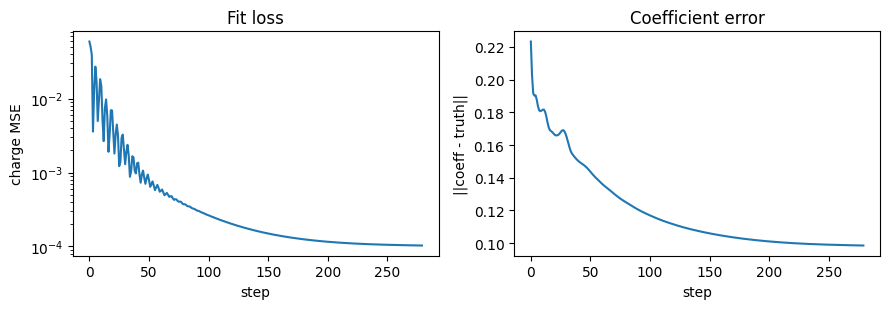

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].semilogy(loss_hist); ax[0].set_xlabel('step'); ax[0].set_ylabel('charge MSE'); ax[0].set_title('Fit loss')
ax[1].plot(err_hist);      ax[1].set_xlabel('step'); ax[1].set_ylabel('||coeff - truth||'); ax[1].set_title('Coefficient error')
plt.tight_layout(); plt.show()

## 4. Recovered field vs. truth

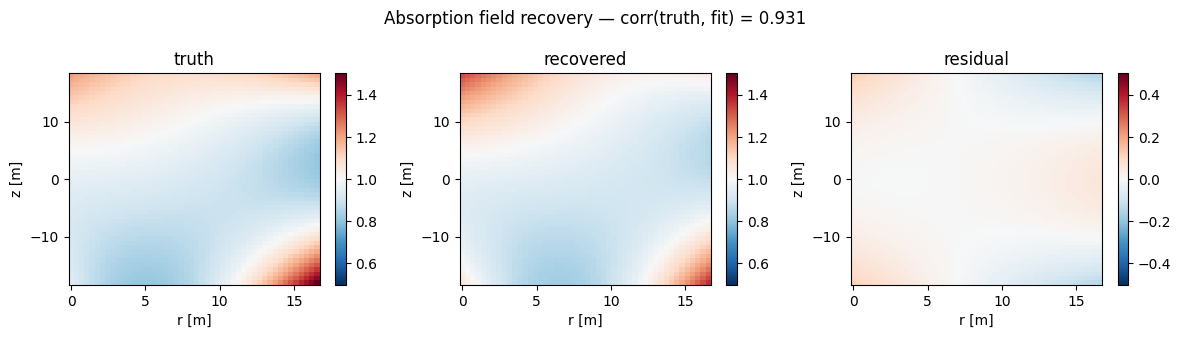

corr=0.931   field-RMS-residual=0.0350   truth-amplitude=0.095


In [5]:
ft, ff = field_map(truth_coeffs), field_map(coeffs)
corr = np.corrcoef(ft.ravel(), ff.ravel())[0, 1]
amp = float(np.abs(ft - 1).max())
panels = [('truth', ft, 1-amp, 1+amp), ('recovered', ff, 1-amp, 1+amp), ('residual', ff-ft, -amp, amp)]
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, (t, m, lo, hi) in zip(ax, panels):
    im = a.pcolormesh(rr, zz, m, cmap='RdBu_r', shading='auto', vmin=lo, vmax=hi)
    a.set_title(t); a.set_xlabel('r [m]'); a.set_ylabel('z [m]'); fig.colorbar(im, ax=a)
plt.suptitle(f'Absorption field recovery — corr(truth, fit) = {corr:.3f}')
plt.tight_layout(); plt.show()
print(f"corr={corr:.3f}   field-RMS-residual={np.sqrt(np.mean((ft-ff)**2)):.4f}   truth-amplitude={np.std(ft):.3f}")

## Notes & caveats

- **Regime.** This is the matched-forward (expected-value) demonstration — the same key and the
  same (known) globals are used for truth and fit, so the gradient cleanly recovers the field's
  **low-order structure** (corr ≈ 0.9+). The residual is the high-order modes, which are only
  weakly constrained: the absorption field is a ~0.3 %-per-fractional-change *whisper* in the
  charge. This is exactly why the low-dim **`poly`** rep is the principled choice — a
  high-capacity SIREN field would overfit shot noise here.
- **Globals first.** The spatial field is the residual *after* the global optics are pinned. In a
  real fit, recover the 7 global optical parameters first (see `calibrate_optics.ipynb` /
  `examples/hello_calibrate.py`), then fit the field. The field is degenerate with `L_abs` (a
  uniform shift); `poly` removes this by construction (no constant mode). For `siren`/`grid`,
  pass `normamp=True` to put the magnitude in one bounded scalar.
- **Coverage.** Use several source positions — a single source leaves parts of the (r, z) volume
  unconstrained.
- **Shot noise.** Real calibration data carries Poisson noise that limits the field resolution
  further; the recoverable field is set by the photon budget and source diversity, not the rep's
  capacity.
- **Persistence.** `field_params` is **not** saved by `save_detector_params` (it round-trips to
  `None`) — re-fit the field at use, since its representation/shape is fixed at setup.
- **Geometry.** The field encoding is cylindrical; non-cylinder detectors are rejected with a
  clear error.